# 1-find the highest bill and the tips 

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

candidate_paths = [
    Path("tips.csv"),
    Path("/mnt/data/tips.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

df = pd.read_csv(data_path)

highest_bill = df.loc[df["total_bill"].idxmax()]

print(f"Gender: {highest_bill['sex']},The highest bill was ${highest_bill['total_bill']:.2f},The tip paid was ${highest_bill['tip']:.2f}")

Gender: Male,The highest bill was $50.81,The tip paid was $10.00


- The highest restaurant bill was paid by a male customer (50.81) and the tips is (10.00)

# 2-find who paid tips more than 3.0

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

candidate_paths = [
    Path("tips.csv"),
    Path("/mnt/data/tips.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
df = pd.read_csv(data_path)
high_tips = df[df["tip"] >= 3]
print(high_tips.groupby("sex").size())

sex
Female    39
Male      82
dtype: int64


- Male customers paid tips of $3 or more more frequently than female customers in this dataset.

# 3-who orders alot

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

candidate_paths = [
    Path("tips.csv"),
    Path("/mnt/data/tips.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
df = pd.read_csv(data_path)
orders = df.groupby("sex")["total_bill"].sum()
print(orders)
print(f"\nThe gender that ordered the most is: {orders.idxmax()}")

sex
Female    1570.95
Male      3256.82
Name: total_bill, dtype: float64

The gender that ordered the most is: Male


- Male customers generated a higher total bill amount than female customers in this dataset.

# 4-what is a hightest time ?

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

candidate_paths = [
    Path("tips.csv"),
    Path("/mnt/data/tips.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
df = pd.read_csv(data_path)
meal_counts = df["time"].value_counts()
print(meal_counts)

time
Dinner    176
Lunch      68
Name: count, dtype: int64


- Dinner is the most frequently ordered meal, accounting for the highest number of restaurant visits.

# 5-hightest day for male , famale

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

candidate_paths = [
    Path("tips.csv"),
    Path("/mnt/data/tips.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
df = pd.read_csv(data_path)
gender_by_day = df.groupby(["day", "sex"]).size().unstack()
male_day = gender_by_day["Male"].idxmax()
female_day = gender_by_day["Female"].idxmax()
print("The day with the most male customers:", male_day)
print("The day with the most female customers:", female_day)

The day with the most male customers: Sat
The day with the most female customers: Thur


- Saturday had the highest number of male customers, while Thursday had the highest number of female customers.


# 6-who paid highest tips

In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

candidate_paths = [
    Path("tips.csv"),
    Path("/mnt/data/tips.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
df = pd.read_csv(data_path)
tip_count = df.groupby("sex")["tip"].count()
print(tip_count)

sex
Female     87
Male      157
Name: tip, dtype: int64


- Male customers account for the highest number of tipping transactions in the dataset

# 7-lunch and dinner

In [15]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

candidate_paths = [
    Path("tips.csv"),
    Path("/mnt/data/tips.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
df = pd.read_csv(data_path)
meal_by_day = df.groupby(["day", "time"]).size().unstack()
print(meal_by_day)

time  Dinner  Lunch
day                
Fri     12.0    7.0
Sat     87.0    NaN
Sun     76.0    NaN
Thur     1.0   61.0


- Lunch orders are concentrated mainly on Thursday, while Dinner is the dominant meal on Friday, Saturday, and Sunday.

# 8-total bill per day 

In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

candidate_paths = [
    Path("tips.csv"),
    Path("/mnt/data/tips.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
df = pd.read_csv(data_path)
total_bill_per_day = df.groupby("day", as_index=False)["total_bill"].sum()
print(total_bill_per_day)

    day  total_bill
0   Fri      325.88
1   Sat     1778.40
2   Sun     1627.16
3  Thur     1096.33


- Saturday generated the highest total bill among all days, indicating that it is the busiest and most profitable day for the restaurant

# 9-total tips per day

In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

candidate_paths = [
    Path("tips.csv"),
    Path("/mnt/data/tips.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
df = pd.read_csv(data_path)
total_bill_per_day = df.groupby("day", as_index=False)["tip"].sum()
print(total_bill_per_day)

    day     tip
0   Fri   51.96
1   Sat  260.40
2   Sun  247.39
3  Thur  171.83


- Saturday recorded the highest total tips among all days.

# 10- predicitions the tips

In [21]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# قراءة البيانات
candidate_paths = [
    Path("tips.csv"),
    Path("/mnt/data/tips.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)
df = pd.read_csv(data_path)

# نسخ البيانات
data = df.copy()

# تحويل الأعمدة النصية إلى أرقام
encoder = LabelEncoder()

data["sex"] = encoder.fit_transform(data["sex"])
data["smoker"] = encoder.fit_transform(data["smoker"])
data["day"] = encoder.fit_transform(data["day"])
data["time"] = encoder.fit_transform(data["time"])

# Features
X = data[["total_bill", "sex", "smoker", "day", "time", "size"]]

# Target
y = data["tip"]

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# إنشاء وتدريب الموديل
model = LinearRegression()
model.fit(X_train, y_train)

# التوقع على بيانات الاختبار
y_pred = model.predict(X_test)

# تقييم الموديل
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

# توقع لعميل جديد
new_customer = pd.DataFrame({
    "total_bill": [50],
    "sex": [1],      # Male
    "smoker": [0],   # No
    "day": [2],
    "time": [0],
    "size": [3]
})

predicted_tip = model.predict(new_customer)

print(f"\nPredicted Tip: ${predicted_tip[0]:.2f}")

R² Score: 0.4441368826121932
MAE: 0.6703807496461157

Predicted Tip: $6.06


- The Linear Regression model provides a reasonable estimate of customer tips. While it explains about 44% of the variation in tipping behavior, its average prediction error is less than one dollar.

## summary

,Statistic,Value
0,Number of Records,244
1,Number of Columns,7
2,Average Bill,19.79
3,Median Bill,17.8
4,Highest Bill,50.81
5,Lowest Bill,3.07
6,Average Tip,3.0
7,Median Tip,2.9
8,Highest Tip,10.0
9,Lowest Tip,1.0


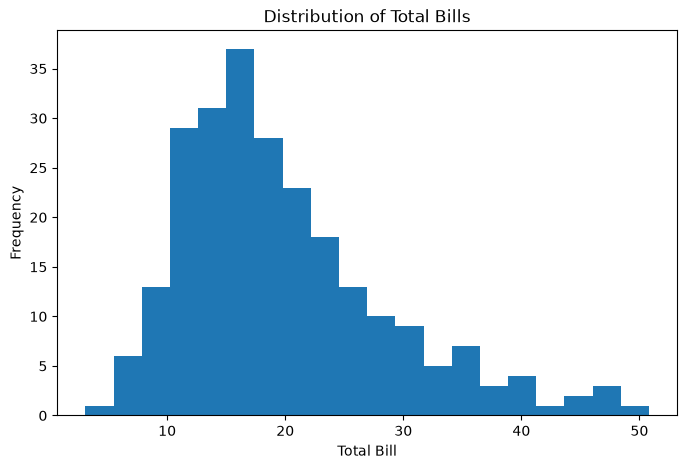

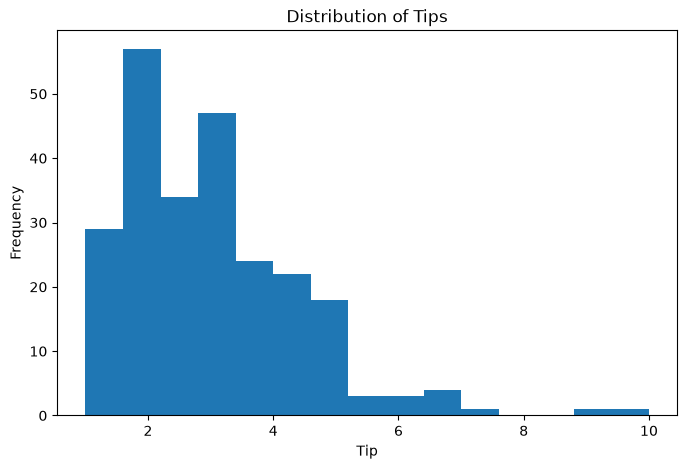

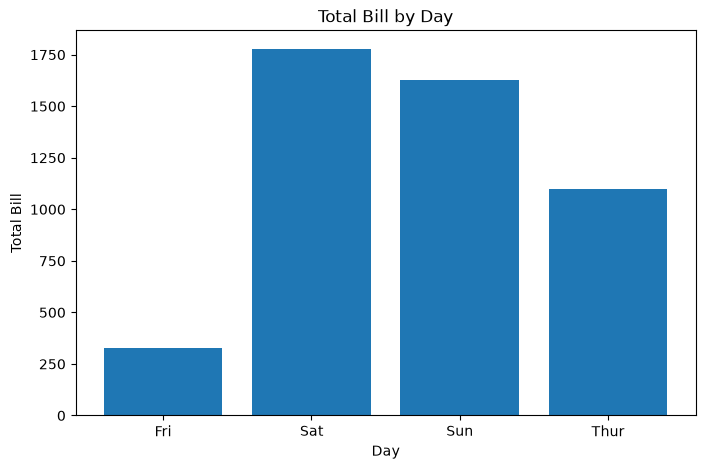

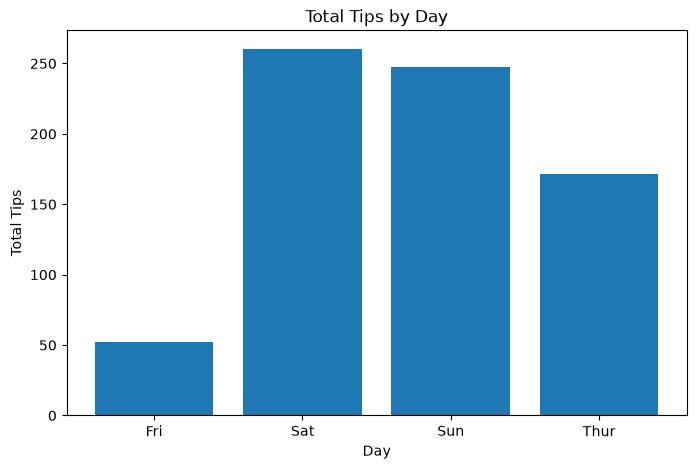

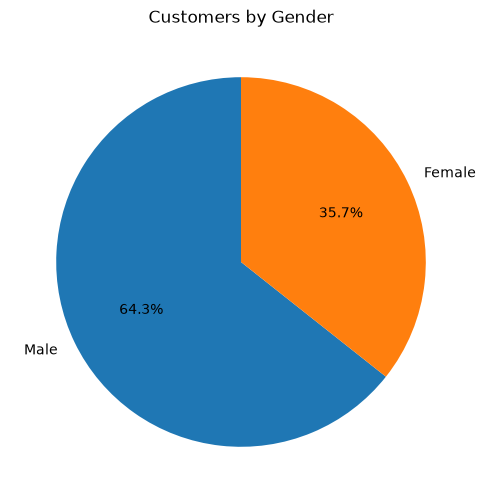

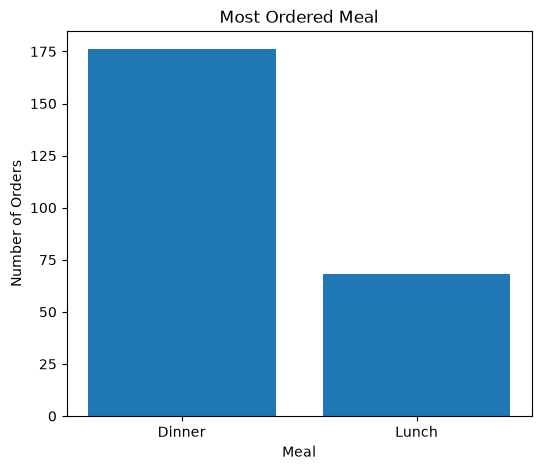

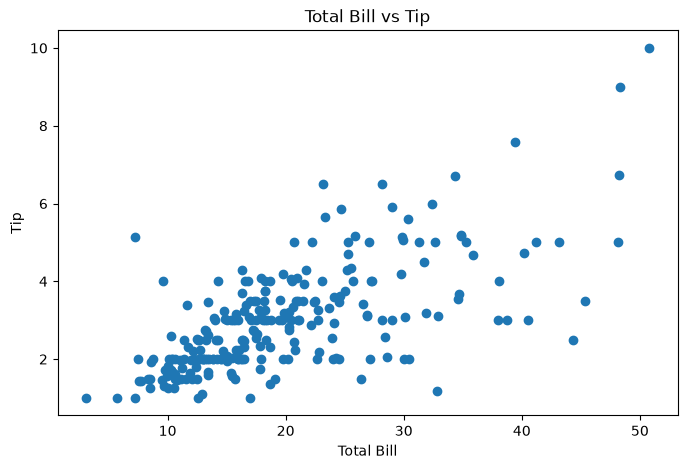

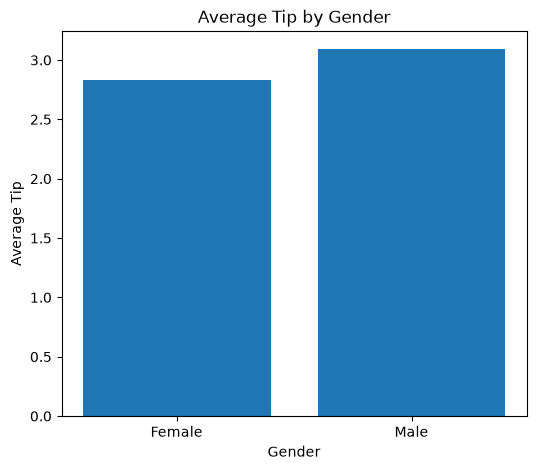

In [27]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
candidate_paths = [
    Path("tips.csv"),
    Path("/mnt/data/tips.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
df = pd.read_csv(data_path)
summary = pd.DataFrame({
    "Statistic": [
        "Number of Records",
        "Number of Columns",
        "Average Bill",
        "Median Bill",
        "Highest Bill",
        "Lowest Bill",
        "Average Tip",
        "Median Tip",
        "Highest Tip",
        "Lowest Tip",
        "Most Common Day",
        "Most Common Time",
        "Most Common Gender",
        "Most Common Smoker Status"
    ],

    "Value": [
        len(df),
        df.shape[1],
        round(df["total_bill"].mean(), 2),
        round(df["total_bill"].median(), 2),
        round(df["total_bill"].max(), 2),
        round(df["total_bill"].min(), 2),
        round(df["tip"].mean(), 2),
        round(df["tip"].median(), 2),
        round(df["tip"].max(), 2),
        round(df["tip"].min(), 2),
        df["day"].mode()[0],
        df["time"].mode()[0],
        df["sex"].mode()[0],
        df["smoker"].mode()[0]
    ]
})
display(summary)
plt.figure(figsize=(8,5))
plt.hist(df["total_bill"], bins=20)
plt.title("Distribution of Total Bills")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.show()
plt.figure(figsize=(8,5))
plt.hist(df["tip"], bins=15)
plt.title("Distribution of Tips")
plt.xlabel("Tip")
plt.ylabel("Frequency")
plt.show()
bill_day = df.groupby("day")["total_bill"].sum()
plt.figure(figsize=(8,5))
plt.bar(bill_day.index, bill_day.values)
plt.title("Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Total Bill")
plt.show()
tips_day = df.groupby("day")["tip"].sum()
plt.figure(figsize=(8,5))
plt.bar(tips_day.index, tips_day.values)
plt.title("Total Tips by Day")
plt.xlabel("Day")
plt.ylabel("Total Tips")
plt.show()
gender = df["sex"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(gender.values,
        labels=gender.index,
        autopct="%1.1f%%",
        startangle=90)
plt.title("Customers by Gender")
plt.show()
meal = df["time"].value_counts()
plt.figure(figsize=(6,5))
plt.bar(meal.index, meal.values)
plt.title("Most Ordered Meal")
plt.xlabel("Meal")
plt.ylabel("Number of Orders")
plt.show()
plt.figure(figsize=(8,5))
plt.scatter(df["total_bill"], df["tip"])
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()
avg_tip = df.groupby("sex")["tip"].mean()
plt.figure(figsize=(6,5))
plt.bar(avg_tip.index, avg_tip.values)
plt.title("Average Tip by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Tip")
plt.show()